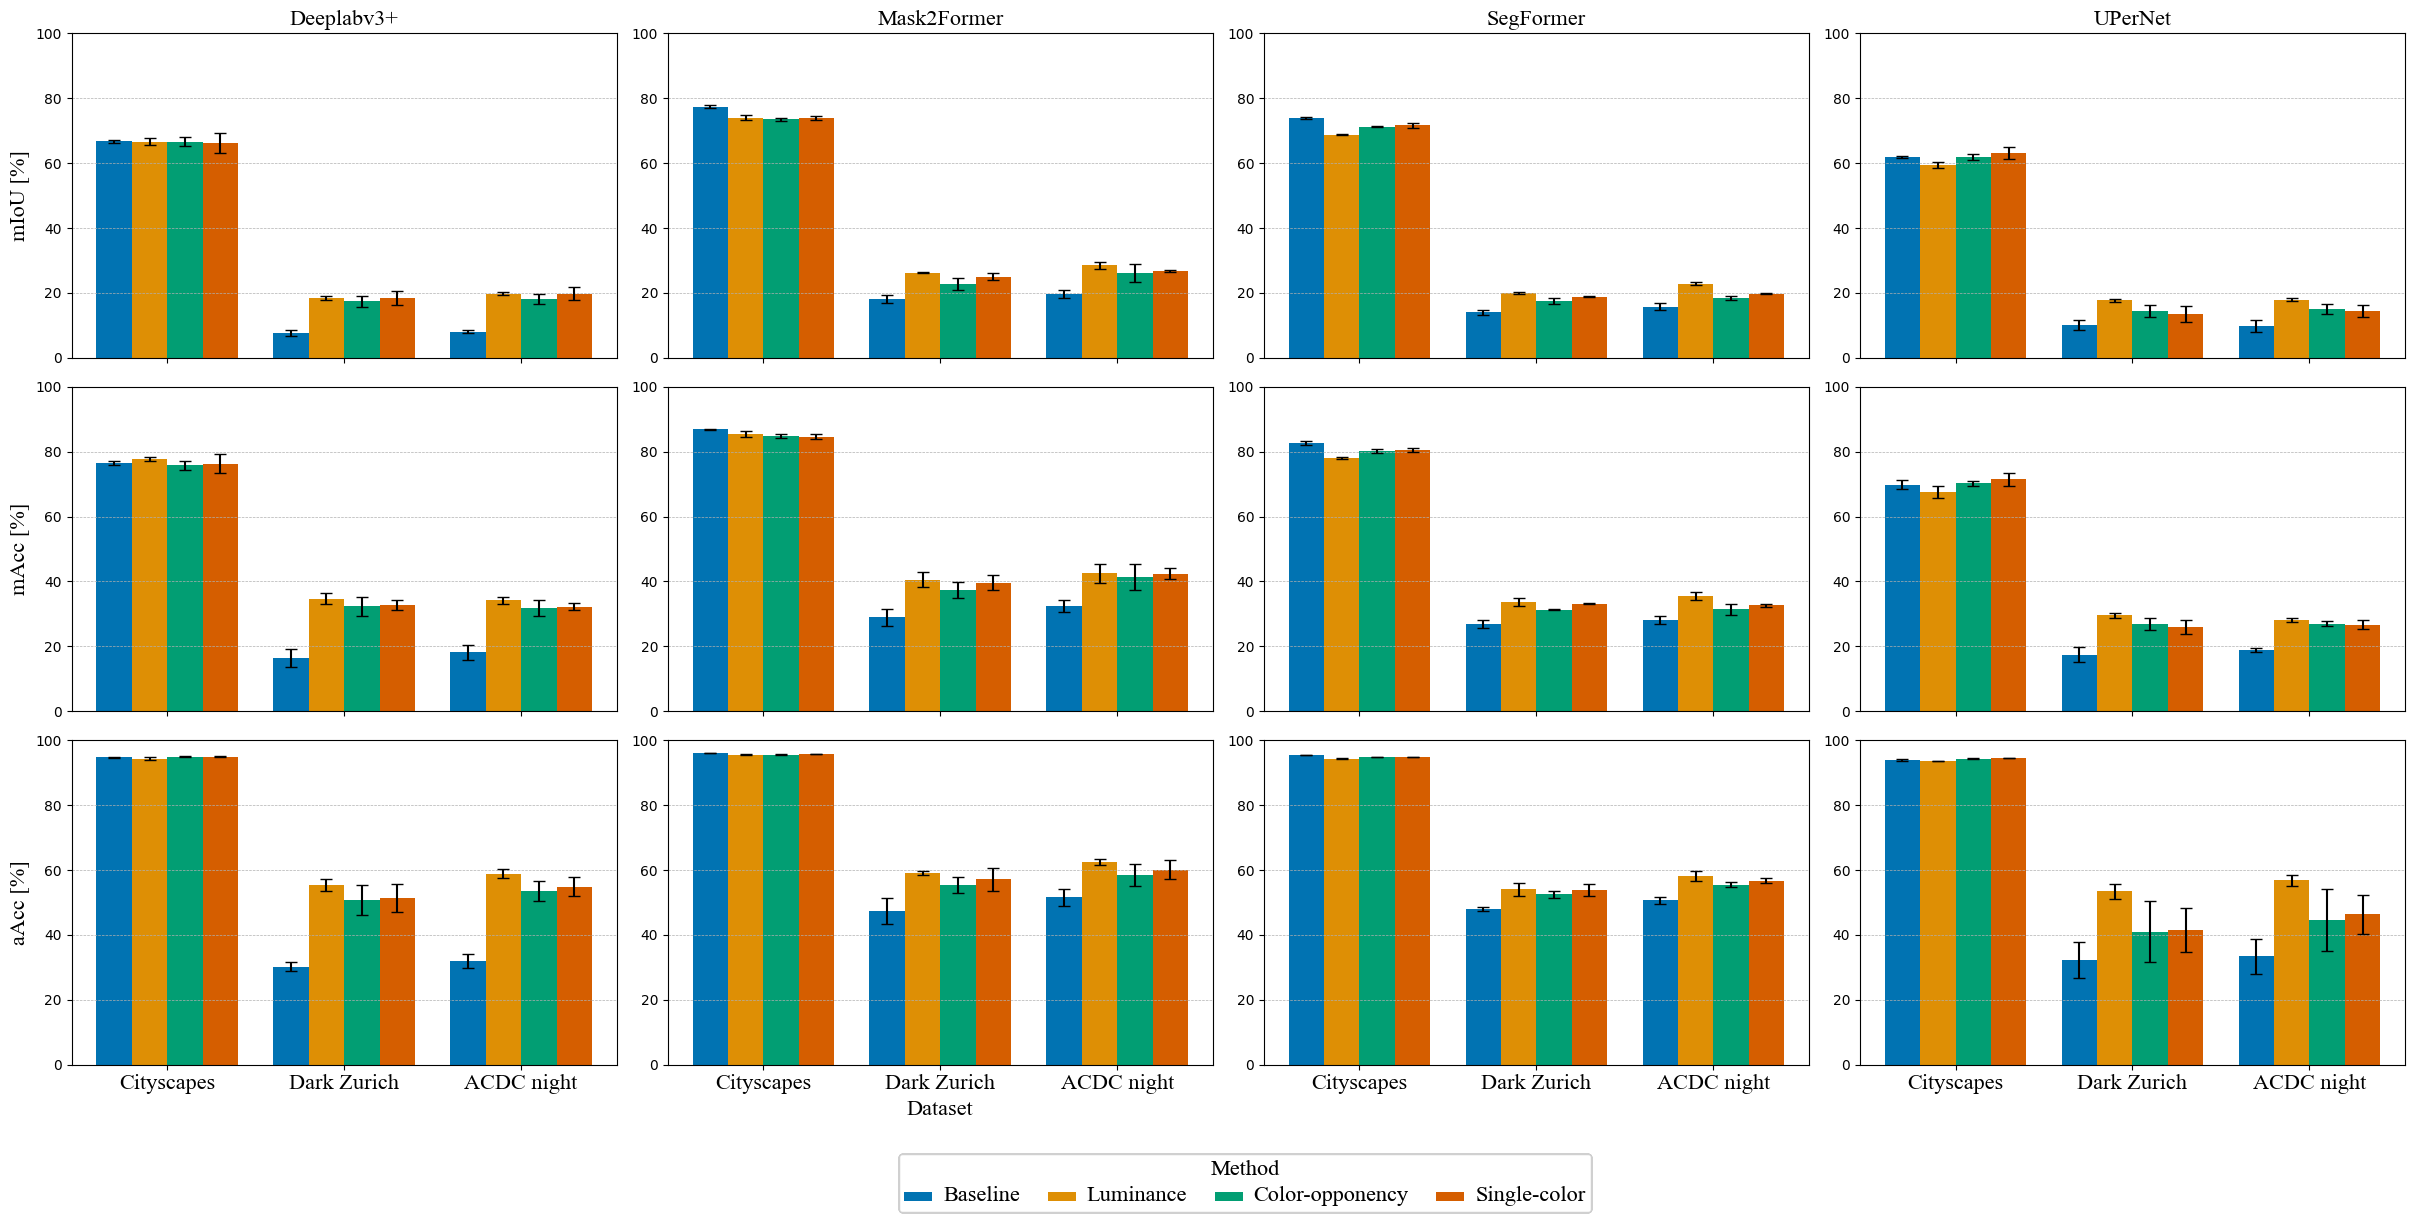

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np
from io import StringIO
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from matplotlib.font_manager import FontProperties
from matplotlib.patches import Patch


font_path = "/home/lstracke/Data/times.ttf"  
times_new_roman = FontProperties(fname=font_path, size=16)
network_list = ["Deeplabv3+", "Mask2Former", "SegFormer", "UPerNet"]


latex_tables = {
    'cityscapes': r"""
    \begin{table*}[h]
    \begin{tabular}{@{}lcccccc@{}}
    \toprule
    Validation on cityscapes & preprocessing &depth & channel  &  aAcc\_mean & mIoU\_mean & mAcc\_mean \\
    \midrule
    deeplabv3plus\_baseline &- & 0& 3 & 94.68 ~$\pm$~ 0.05 & \textbf{66.68} ~$\pm$~ 0.44 & 76.58 ~$\pm$~ 0.60 \\
    deeplabv3plus\_bw &bw\_average & 5& 3 & 94.35 ~$\pm$~ 0.35 & 66.53 ~$\pm$~ 1.11 & 77.86 ~$\pm$~ 0.63 \\
    deeplabv3plus\_co &co & 5& 3 & 94.88 ~$\pm$~ 0.15 & 66.64 ~$\pm$~ 1.39 & 75.80  ~$\pm$~ 1.46 \\
    deeplabv3plus\_sc &sc & 5& 3 & 94.90  ~$\pm$~ 0.16 & 66.08~$\pm$~ 3.05 & 76.33 ~$\pm$~ 3.03 \\
    \midrule
    mask2former\_baseline &- & 0& 3& 96.10 ~$\pm$~ 0.05 & 77.43 ~$\pm$~ 0.35 & 86.83 ~$\pm$~ 0.19 \\
    mask2former\_bw &bw\_average & 5& 3& 95.59 ~$\pm$~ 0.13 & 73.93 ~$\pm$~ 0.80 & 85.33 ~$\pm$~ 0.92  \\
    mask2former\_co &co & 5& 3& 95.54 ~$\pm$~ 0.11 & 73.47 ~$\pm$~ 0.47 & 84.86 ~$\pm$~ 0.57  \\
    mask2former\_sc &sc & 5& 3& 95.75 ~$\pm$~ 0.02 & 74.02 ~$\pm$~ 0.62 & 84.64 ~$\pm$~ 0.85  \\
    \midrule
    segformer\_baseline &- & 0& 3 & 95.36~$\pm$~ 0.03 & \textbf{73.86} ~$\pm$~ 0.29 & 82.58 ~$\pm$~ 0.59\\
    segformer\_bw &bw\_average & 5& 3 & 94.30~$\pm$~0.10&68.73~$\pm$~0.20&77.97~$\pm$~0.38\\
    segformer\_co &co & 5& 3 & 94.80~$\pm$~0.05&71.26~$\pm$~0.16&80.22~$\pm$~0.58\\
    segformer\_sc &sc & 5& 3 & 94.79~$\pm$~0.09&71.59~$\pm$~0.67&80.56~$\pm$~0.59\\
    \midrule
    internImage\_baseline &- & 0& 3 & 94.01 ~$\pm$~ 0.34 & 61.87 ~$\pm$~ 0.21 & 69.87 ~$\pm$~ 1.49 \\
    internImage\_bw &bw\_average & 5& 3 & 93.70  ~$\pm$~ 0.044 & 59.50 ~$\pm$~ 0.94 & 67.65 ~$\pm$~ 1.91 \\
    internImage\_co &co & 5& 3 & 94.35 ~$\pm$~ 0.12 & 61.93 ~$\pm$~ 0.88 & 70.28 ~$\pm$~ 0.72 \\
    internImage\_sc &sc & 5& 3 & 94.45 ~$\pm$~ 0.07  & \textbf{63.17} ~$\pm$~ 1.77 & 71.45 ~$\pm$~ 2.05 \\
    \end{tabular}
    """,

    'dark_zurich': r"""
    \begin{table*}[h]
    \begin{tabular}{@{}lcccccc@{}}
    \toprule
    Validation on dark\_zurich & preprocessing &depth & channel  &  aAcc\_mean & mIoU\_mean & mAcc\_mean \\
    \midrule
    deeplabv3plus\_baseline &- & 0& 3 & 30.13 ~$\pm$~ 1.41 & 7.64 ~$\pm$~ 1.00 & 16.40 ~$\pm$~ 2.74 \\
    deeplabv3plus\_bw &bw\_average & 5& 3 & 55.35 ~$\pm$~ 1.81 & 18.39 ~$\pm$~ 0.54 & 34.73 ~$\pm$~ 1.68 \\
    deeplabv3plus\_co &co & 5& 3 & 50.68 ~$\pm$~ 4.61 & 17.46 ~$\pm$~ 1.70 & 32.32 ~$\pm$~ 2.85 \\
    deeplabv3plus\_sc &sc & 5& 3 & 51.35 ~$\pm$~ 4.26 & \textbf{18.54} ~$\pm$~ 2.18 & 32.79 ~$\pm$~ 1.49 \\
    \midrule
    mask2former\_baseline &- & 0& 3& 47.34 ~$\pm$~ 4.13 & 18.16 ~$\pm$~ 1.14 & 28.88 ~$\pm$~ 2.72  \\
    mask2former\_bw &bw\_average & 5& 3& 59.16 ~$\pm$~ 0.58 & 26.21 ~$\pm$~ 0.18 & 40.56 ~$\pm$~ 2.23  \\
    mask2former\_co &co & 5& 3& 55.26 ~$\pm$~ 2.45 & 22.84 ~$\pm$~ 1.82 & 37.37 ~$\pm$~ 2.58  \\
    mask2former\_sc &sc & 5& 3& 57.09 ~$\pm$~ 3.52 & 24.92 ~$\pm$~ 1.09 & 39.64 ~$\pm$~ 2.37  \\
    \midrule
    segformer\_baseline &- & 0& 3 & 47.96 ~$\pm$~0.57&13.95 ~$\pm$~0.79&26.98 ~$\pm$~1.19\\
    segformer\_bw &bw\_average & 5& 3 & 54.02 ~$\pm$~1.98&\textbf{19.99} ~$\pm$~0.31&33.67 ~$\pm$~1.31\\
    segformer\_co &co & 5& 3 & 52.46 ~$\pm$~1.01&17.50 ~$\pm$~0.82&31.33 ~$\pm$~0.12\\
    segformer\_sc &sc & 5& 3 & 53.88 ~$\pm$~1.79&18.76 ~$\pm$~0.13&33.11 ~$\pm$~0.19\\
    \midrule
    internImage\_baseline &- & 0& 3 & 32.28 ~$\pm$~ 5.55 & 10.07 ~$\pm$~ 1.49 & 17.46 ~$\pm$~ 2.39 \\
    internImage\_bw &bw\_average & 5& 3 & 53.40 ~$\pm$~ 2.25 & \textbf{17.66} ~$\pm$~ 0.47 & 29.58 ~$\pm$~ 0.75 \\
    internImage\_co &co & 5& 3 & 40.99 ~$\pm$~ 9.39 & 14.31 ~$\pm$~ 1.88 & 26.85 ~$\pm$~ 1.97 \\
    internImage\_sc &sc & 5& 3 & 41.43 ~$\pm$~ 6.72 & 13.47 ~$\pm$~ 2.45 & 25.99 ~$\pm$~ 2.23 \\
    \end{tabular}
    """,

    'acdc_night': r"""
    \begin{table*}[h]
    \centering
    \begin{tabular}{@{}lcccccc@{}}
    \toprule
    Validation on acdc\_night & preprocessing &depth & channel  &  aAcc\_mean & mIoU\_mean & mAcc\_mean \\
    \midrule
    deeplabv3plus\_baseline &- & 0& 3 & 31.94 ~$\pm$~ 2.20 & 8.01  ~$\pm$~ 0.45 & 18.14 ~$\pm$~ 2.24 \\
    deeplabv3plus\_bw &bw\_average & 5& 3 & 58.90 ~$\pm$~ 1.33 & \textbf{19.76} ~$\pm$~ 0.53 & 34.13 ~$\pm$~ 1.05 \\
    deeplabv3plus\_co &co & 5& 3 & 53.51 ~$\pm$~ 3.20 & 18.05 ~$\pm$~ 1.55 & 31.73 ~$\pm$~ 2.54 \\
    deeplabv3plus\_sc &sc & 5& 3 & 54.79 ~$\pm$~ 2.95 & 19.75 ~$\pm$~ 1.99 & 32.24 ~$\pm$~ 1.17 \\
    \midrule
    mask2former\_baseline &- & 0& 3& 51.57 ~$\pm$~ 2.56 & 19.65 ~$\pm$~ 1.22 & 32.32 ~$\pm$~ 1.80  \\
    mask2former\_bw &bw\_average & 5& 3& 62.43 ~$\pm$~ 0.83 & 28.45 ~$\pm$~ 1.18 & 42.50 ~$\pm$~ 2.86  \\
    mask2former\_co &co & 5& 3& 58.44 ~$\pm$~ 3.31 & 26.08 ~$\pm$~ 2.72 & 41.45 ~$\pm$~ 3.98  \\
    mask2former\_sc &sc & 5& 3& 60.03 ~$\pm$~ 2.94 & 26.64 ~$\pm$~ 0.26 & 42.38 ~$\pm$~ 1.67  \\
    \midrule
    segformer\_baseline &- & 0& 3 & 50.68~$\pm$~1.11&15.76~$\pm$~1.09&28.11~$\pm$~1.16\\
    segformer\_bw &bw\_average & 5& 3 & 58.25~$\pm$~1.50&\textbf{22.84}~$\pm$~0.50&35.40~$\pm$~1.27\\
    segformer\_co &co & 5& 3 & 55.52~$\pm$~0.89&18.40~$\pm$~0.51&31.41~$\pm$~1.63\\
    segformer\_sc &sc & 5& 3 & 56.70~$\pm$~0.86&19.78~$\pm$~0.13&32.70~$\pm$~0.48\\
    \midrule
    internImage\_baseline &- & 0& 3 & 33.43 ~$\pm$~ 5.45 & 9.64 ~$\pm$~ 1.84 & 19.00 ~$\pm$~ 0.63 \\
    internImage\_bw &bw\_average & 5& 3 & 56.82 ~$\pm$~ 1.61 & \textbf{17.89} ~$\pm$~ 0.43 & 28.10 ~$\pm$~ 0.75 \\
    internImage\_co &co & 5& 3 & 44.51 ~$\pm$~ 9.51 & 15.09 ~$\pm$~ 1.49 & 27.03 ~$\pm$~ 0.89 \\
    internImage\_sc &sc & 5& 3 & 46.29 ~$\pm$~ 6.03 & 14.30 ~$\pm$~ 1.86 & 26.64 ~$\pm$~ 1.33 \\
    \end{tabular}
    """
}


import re


def extract_val_std(s):

    s = s.replace('$', '').replace('~', '').strip()

 
    s = re.sub(r'\\?pm', '|', s)



    if '|' in s:
        parts = s.split('|')
    else:
        parts = s.split()

    parts = [p.strip() for p in parts if p.strip()]

    if len(parts) == 2:
        return float(parts[0]), float(parts[1])
    elif len(parts) == 1:
        return float(parts[0]), 0.0
    else:
        raise ValueError(f"Unrecognized format: '{s}', parts: {parts}")



all_rows = []
for dataset, latex in latex_tables.items():
    for line in latex.splitlines():
        if '&' in line and '~' in line:

            line = re.sub(r'\\\\\s*$', '', line)

            line_clean = re.sub(r'\\(?!pm)[a-zA-Z]+\*?', '', line)

    
            line_clean = re.sub(r'[^a-zA-Z0-9.\-_&\s\\]', '', line_clean)

            parts = [p.strip() for p in line_clean.split('&')]

            if len(parts) == 7:
                run, prep, depth, channel, aAcc_str, mIoU_str, mAcc_str = parts
                aAcc_mean, aAcc_std = extract_val_std(aAcc_str)
                mIoU_mean, mIoU_std = extract_val_std(mIoU_str)
                mAcc_mean, mAcc_std = extract_val_std(mAcc_str)
                model, method = run.split('_', 1)
                all_rows.append({
                    'dataset': dataset,
                    'run': run,
                    'model': model,
                    'method': method,
                    'preprocessing': prep,
                    'depth': int(depth),
                    'channel': int(channel),
                    'aAcc_mean': aAcc_mean,
                    'aAcc_std': aAcc_std,
                    'mIoU_mean': mIoU_mean,
                    'mIoU_std': mIoU_std,
                    'mAcc_mean': mAcc_mean,
                    'mAcc_std': mAcc_std,
                })

df = pd.DataFrame(all_rows)


label_map = {
    'baseline': 'Baseline',
    'bw': 'Luminance',
    'co': 'Color-opponency',
    'sc': 'Single-color'
}
method_prefixes = list(label_map.keys())
palette = sns.color_palette("colorblind", n_colors=len(method_prefixes))
color_map = {prefix: palette[i] for i, prefix in enumerate(method_prefixes)}

def get_method_color(method_name):
    for prefix in method_prefixes:
        if method_name.startswith(prefix):
            return color_map[prefix]
    return 'gray' 

def get_method_label(method_name):
    for prefix in method_prefixes:
        if method_name.startswith(prefix):
            return label_map[prefix]
    return method_name


method_order = sorted(df['method'].unique())  
metrics = [
    ('mIoU_mean', 'mIoU_std', 'mIoU [%]'),
    ('mAcc_mean', 'mAcc_std', 'mAcc [%]'),
    ('aAcc_mean', 'aAcc_std', 'aAcc [%]')
]
datasets_order = ["cityscapes", "dark_zurich", "acdc_night"]
x = np.arange(len(datasets_order))
group_width = 0.8
bar_width = group_width / len(method_order)


fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(25, 12), sharex='col')

for row_idx, (mean_col, std_col, ylabel) in enumerate(metrics):
    for col_idx, model in enumerate(df['model'].unique()):
        ax = axes[row_idx, col_idx]
        subset = df[df['model'] == model]

        for i, method in enumerate(method_order):
            method_data = subset[subset['method'] == method]
            if not method_data.empty:
                means = []
                stds = []
                positions = x - group_width / 2 + i * bar_width + bar_width / 2

                for ds in datasets_order:
                    row = method_data[method_data['dataset'] == ds]
                    if not row.empty:
                        mean_val = row[mean_col].values[0]
                        std_val = row[std_col].values[0]
                        means.append(row[mean_col].values[0])
                        stds.append(row[std_col].values[0])
                    else:
                        means.append(0.0)
                        stds.append(0.0)
                  

                color = get_method_color(method)
                label = get_method_label(method)

                ax.bar(
                    positions,
                    means,
                    yerr=stds,
                    capsize=4,
                    width=bar_width,
                    color=color,
                    edgecolor=color,
                    linewidth=0,
                    label=label
                )


        if col_idx == 0:
            ax.set_ylabel(ylabel, fontproperties=times_new_roman)


        ax.set_xticks(x)
        if row_idx == 2:
            if col_idx == 1:
  
                ax.set_xlabel("Dataset", fontproperties=times_new_roman)
            ax.set_xticklabels(["Cityscapes", "Dark Zurich", "ACDC night"], fontproperties=times_new_roman)
        else:
            ax.set_xticklabels([])


        if row_idx == 0:
            ax.set_title(network_list[col_idx], fontproperties=times_new_roman)

        ax.grid(True, axis='y', linestyle='--', linewidth=0.5)
        ax.set_ylim(0, 100)

      
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        legend = fig.legend(
            by_label.values(),
            by_label.keys(),
            title="Method",
            loc="lower center",
            bbox_to_anchor=(0.5, -0.02),
            ncol=4,
        )
        for text in legend.get_texts():
            text.set_fontproperties(times_new_roman)
        legend.get_title().set_fontproperties(times_new_roman)



fig.tight_layout(rect=[0, 0.05, 0.97, 1])
plt.show()
#plt.savefig("visualization/main_experiment_appendix.pdf", dpi=800)
#df.to_csv("visualization/main_experiment_appendix.csv", index=False)





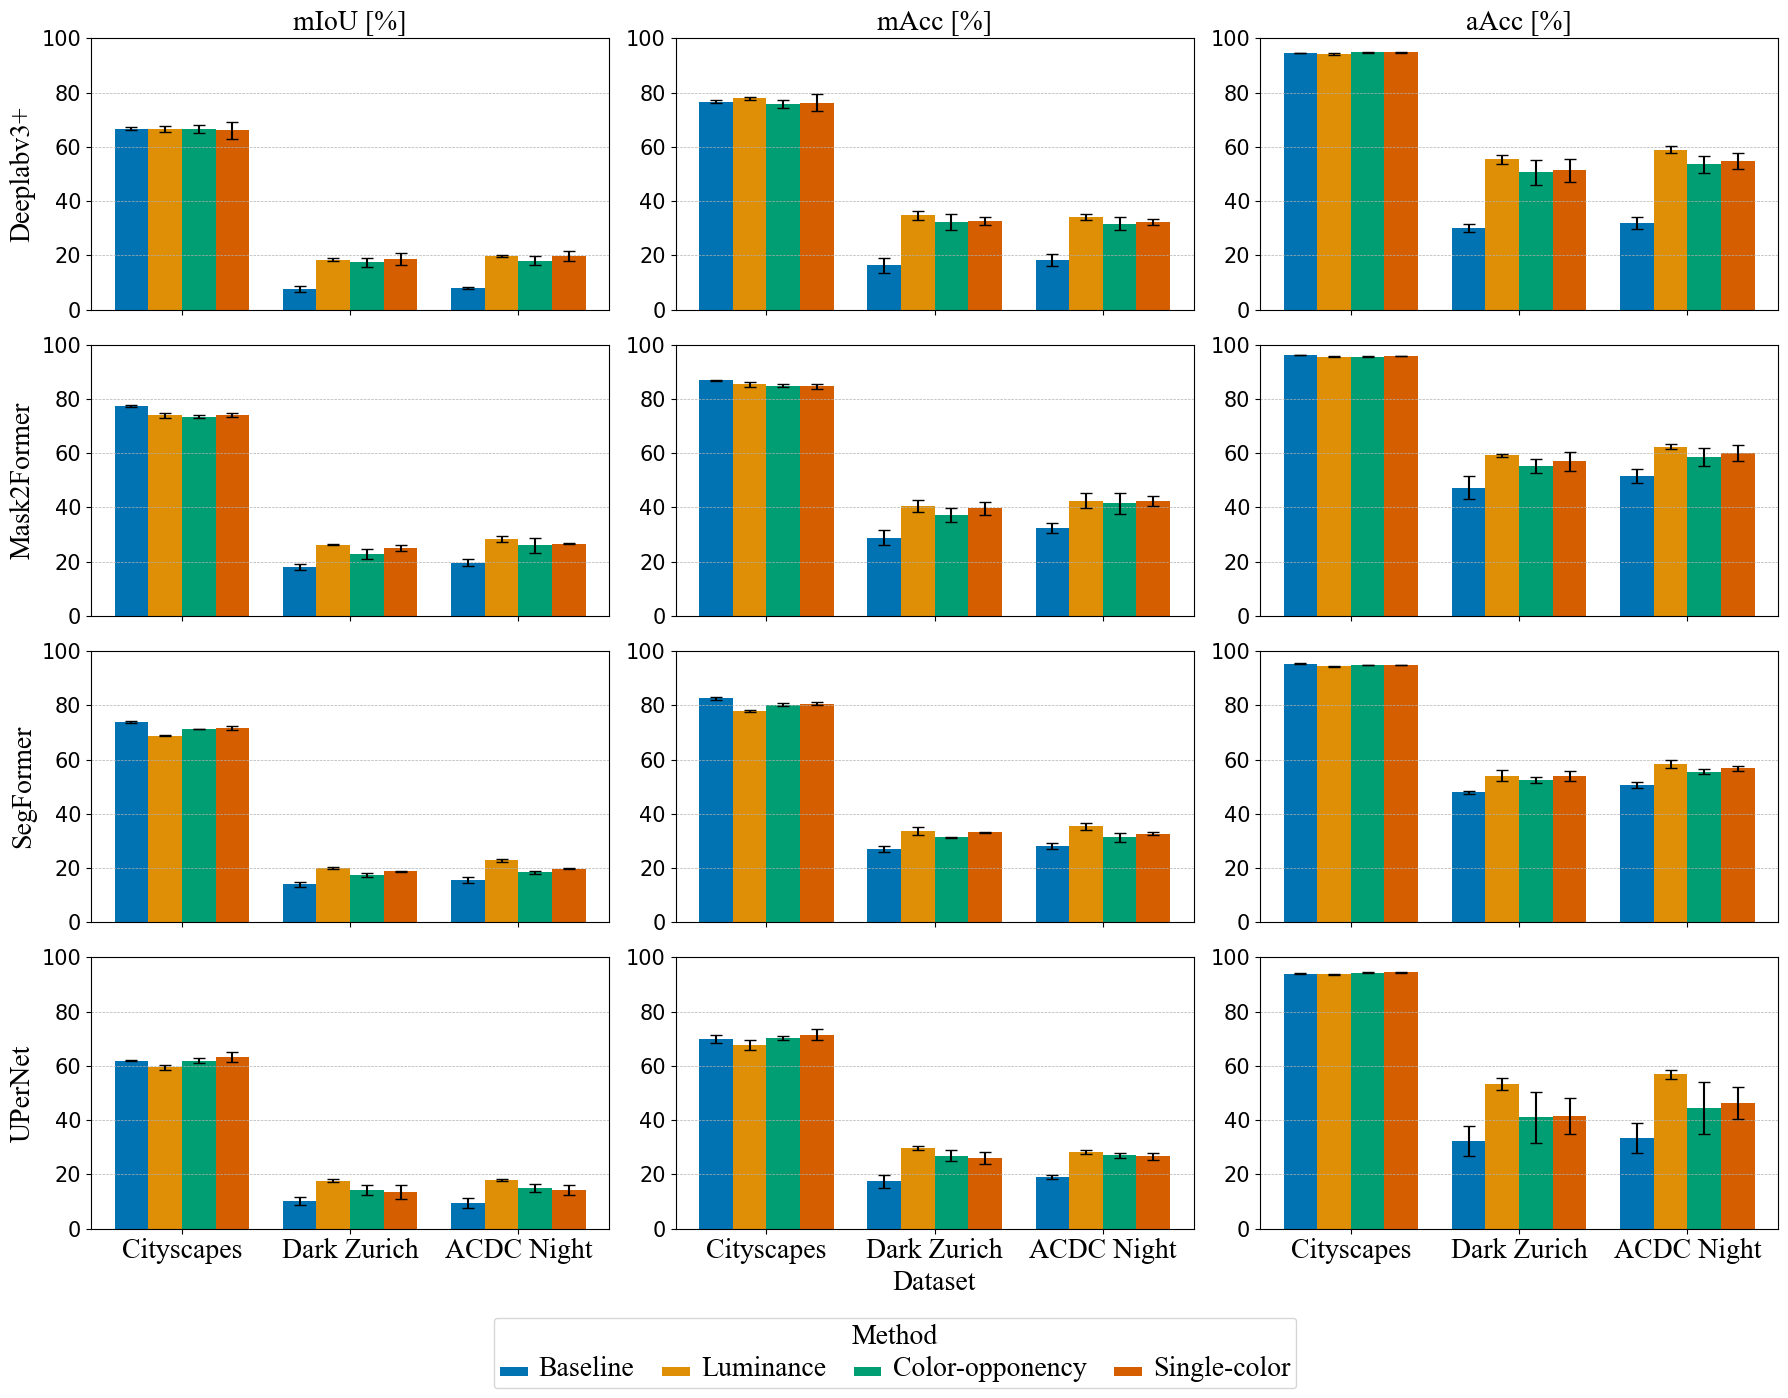

In [29]:


metrics = [
    ('mIoU_mean', 'mIoU_std', 'mIoU [%]'),
    ('mAcc_mean', 'mAcc_std', 'mAcc [%]'),
    ('aAcc_mean', 'aAcc_std', 'aAcc [%]')
]

datasets_order = ["cityscapes", "dark_zurich", "acdc_night"]
dataset_labels = ["Cityscapes", "Dark Zurich", "ACDC Night"]

models = df['model'].unique()

x = np.arange(len(datasets_order))
group_width = 0.8
bar_width = group_width / len(method_prefixes)



fig, axes = plt.subplots(
    nrows=len(models),
    ncols=len(metrics),
    figsize=(18, 14),
    sharex=True
)



for row, model in enumerate(models):

    model_df = df[df['model'] == model]

    for col, (mean_col, std_col, metric_label) in enumerate(metrics):

        ax = axes[row, col]

        for i, prefix in enumerate(method_prefixes):

            method_df = model_df[model_df['method'].str.startswith(prefix)]

            means = []
            stds = []

            for ds in datasets_order:

                row_data = method_df[method_df['dataset'] == ds]

                if not row_data.empty:
                    means.append(row_data[mean_col].values[0])
                    stds.append(row_data[std_col].values[0])
                else:
                    means.append(0)
                    stds.append(0)

            positions = x - group_width/2 + i*bar_width + bar_width/2

            ax.bar(
                positions,
                means,
                yerr=stds,
                capsize=4,
                width=bar_width,
                color=color_map[prefix],
                edgecolor=color_map[prefix],
                linewidth=0,
                label=label_map[prefix]
            )


        if row == 0:
            ax.set_title(metric_label, fontproperties=times_new_roman, fontsize=20)
            
        if row == 3:
            if col==1:
                ax.set_xlabel("Dataset", fontproperties=times_new_roman, fontsize=20)

        if col == 0:
            ax.set_ylabel(network_list[row], fontproperties=times_new_roman, fontsize=20)

        ax.set_ylim(0, 100)
        ax.tick_params(axis='y', labelsize=15)
        ax.set_xticks(x)

        if row == len(models) - 1:
            ax.set_xticklabels(dataset_labels, fontproperties=times_new_roman, fontsize=20)
        else:
            ax.set_xticklabels([])


        ax.grid(True, axis='y', linestyle='--', linewidth=0.5)


handles = [
    Patch(facecolor=color_map[p], label=label_map[p])
    for p in method_prefixes
]

legend = fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.00),
    ncol=4,
    title="Method"
)


for text in legend.get_texts():
    text.set_fontproperties(times_new_roman)
    text.set_fontsize(20)

legend.get_title().set_fontproperties(times_new_roman)
legend.get_title().set_fontsize(20)


fig.tight_layout(rect=[0,0.06,1,1])
plt.savefig("/home/lstracke/blur_preprocessing/blur_preprocessing_git/visualization/main_experiment_appendix.pdf", dpi=800)
df.to_csv("/home/lstracke/blur_preprocessing/blur_preprocessing_git/visualization/main_experiment_appendix.csv", index=False)
plt.show()


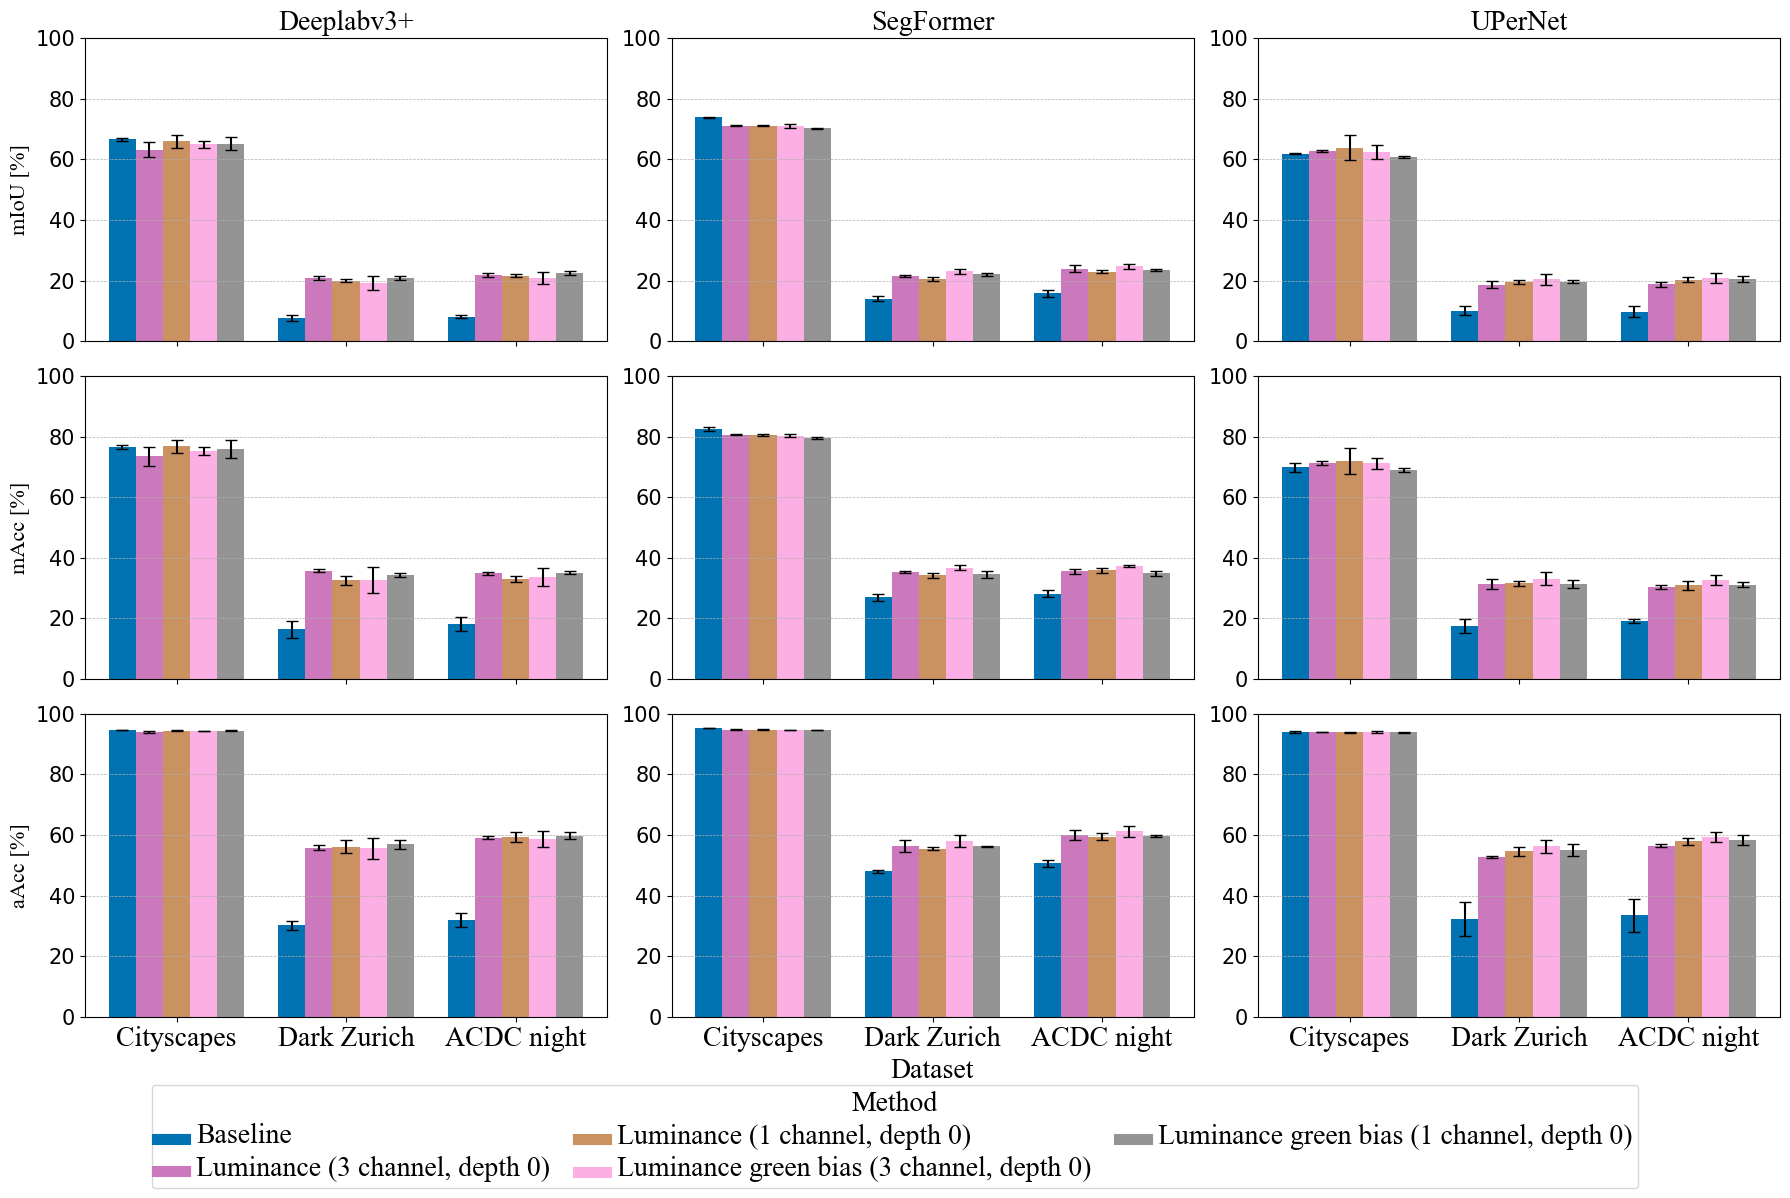

In [ ]:

# Pfad zu Times New Roman (auf deinem System anpassen!)
font_path = "/home/lstracke/Data/times.ttf"  # Beispiel Linux-Pfad
times_new_roman = FontProperties(fname=font_path, size=16)
network_list = ["Deeplabv3+", "SegFormer", "UPerNet"]


latex_tables = {
    'cityscapes': r"""
    \begin{table*}[h]
    \begin{tabular}{@{}lcccccc@{}}
    \toprule
    Network & Preprocessing & Channel & aAcc & mIoU & mAcc \\
    \midrule
    deeplabv3plus & - & 3 & 94.68  ~$\pm$~ 0.05 & 66.68  ~$\pm$~ 0.44 & 76.58  ~$\pm$~ 0.60 \\
    deeplabv3plus & bw\_average & 3 & 94.03  ~$\pm$~ 0.40 & 63.25  ~$\pm$~ 2.45 & 73.53  ~$\pm$~ 3.16 \\
    deeplabv3plus & bw\_average & 1 & 94.47  ~$\pm$~ 0.27 & 66.02  ~$\pm$~ 2.18 & 76.76  ~$\pm$~ 2.09 \\
    deeplabv3plus & bw\_green\_bias & 3 & 94.31  ~$\pm$~ 0.13 & 64.97  ~$\pm$~ 1.19 & 75.34  ~$\pm$~ 1.28 \\
    deeplabv3plus & bw\_green\_bias & 1 & 94.42  ~$\pm$~ 0.16 & 65.14  ~$\pm$~ 2.13 & 75.94  ~$\pm$~ 2.88 \\
    segformer & - & 3 & 95.36 ~$\pm$~0.03 & 73.86 ~$\pm$~0.29 & 82.58 ~$\pm$~0.59 \\
    segformer & bw\_average & 3 & 94.82 ~$\pm$~0.06 & 71.19 ~$\pm$~0.32 & 80.56 ~$\pm$~0.18 \\
    segformer & bw\_average & 1 & 94.81 ~$\pm$~0.06 & 71.13 ~$\pm$~0.23 & 80.50 ~$\pm$~0.22 \\
    segformer & bw\_green\_bias & 3 & 94.76 ~$\pm$~0.03 & 71.03 ~$\pm$~0.56 & 80.37 ~$\pm$~0.36 \\
    segformer & bw\_green\_bias & 1 & 94.75 ~$\pm$~0.02 & 70.25 ~$\pm$~0.16 & 79.57 ~$\pm$~0.21 \\
    internImage & - & 3 & 94.01  ~$\pm$~ 0.34 & 61.87  ~$\pm$~ 0.21 & 69.87  ~$\pm$~ 1.49 \\
    internImage & bw\_average & 3 & 94.00  ~$\pm$~ 0.13 & 62.84  ~$\pm$~ 0.41 & 71.32  ~$\pm$~ 0.66 \\
    internImage & bw\_average & 1 & 93.89  ~$\pm$~ 0.20 & 63.87  ~$\pm$~ 4.03 & 71.94  ~$\pm$~ 4.24 \\
    internImage & bw\_green\_bias & 3 & 93.89  ~$\pm$~ 0.31 & 62.51  ~$\pm$~ 2.38 & 71.15  ~$\pm$~ 1.94 \\
    internImage & bw\_green\_bias & 1 & 93.93  ~$\pm$~ 0.17 & 60.90  ~$\pm$~ 0.30 & 69.00  ~$\pm$~ 0.71 \\
    \end{tabular}
    """,

    'dark_zurich': r"""
    \begin{table*}[h]
    \begin{tabular}{@{}lcccccc@{}}
    \toprule
    Network & Preprocessing & Channel & aAcc & mIoU & mAcc \\
    \midrule
    deeplabv3plus & - & 3 & 30.13  ~$\pm$~ 1.41 & 7.64  ~$\pm$~ 1.00 & 16.40  ~$\pm$~ 2.74 \\
    deeplabv3plus & bw\_average & 3 & 55.78  ~$\pm$~ 0.81 & 20.79  ~$\pm$~ 0.61 & 35.69  ~$\pm$~ 0.49 \\
    deeplabv3plus & bw\_average & 1 & 56.13  ~$\pm$~ 2.24 & 19.92  ~$\pm$~ 0.55 & 32.51  ~$\pm$~ 1.51 \\
    deeplabv3plus & bw\_green\_bias & 3 & 55.59  ~$\pm$~ 3.38 & 19.04  ~$\pm$~ 2.31 & 32.55  ~$\pm$~ 4.29 \\
    deeplabv3plus & bw\_green\_bias & 1 & 56.87  ~$\pm$~ 1.45 & 20.89  ~$\pm$~ 0.64 & 34.28  ~$\pm$~ 0.80 \\
    segformer & - & 3 & 47.96 ~$\pm$~0.57 & 13.95 ~$\pm$~0.79 & 26.98 ~$\pm$~1.19 \\
    segformer & bw\_average & 3 & 56.24 ~$\pm$~1.97 & 21.47 ~$\pm$~0.23 & 35.31 ~$\pm$~0.35 \\
    segformer & bw\_average & 1 & 55.46 ~$\pm$~0.42 & 20.55 ~$\pm$~0.73 & 34.22 ~$\pm$~0.90 \\
    segformer & bw\_green\_bias & 3 & 57.91 ~$\pm$~2.01 & 22.98 ~$\pm$~0.82 & 36.78 ~$\pm$~0.94 \\
    segformer & bw\_green\_bias & 1 & 56.23 ~$\pm$~0.13 & 22.06 ~$\pm$~0.48 & 34.47 ~$\pm$~1.01 \\
    internImage & - & 3 & 32.28  ~$\pm$~ 5.55 & 10.07  ~$\pm$~ 1.49 & 17.46  ~$\pm$~ 2.39 \\
    internImage & bw\_average & 3 & 52.80  ~$\pm$~ 0.41 & 18.61  ~$\pm$~ 1.09 & 31.30  ~$\pm$~ 1.55 \\
    internImage & bw\_average & 1 & 54.58  ~$\pm$~ 1.51 & 19.63  ~$\pm$~ 0.62 & 31.52  ~$\pm$~ 0.78 \\
    internImage & bw\_green\_bias & 3 & 56.29  ~$\pm$~ 2.14 & 20.34  ~$\pm$~ 1.87 & 33.09  ~$\pm$~ 2.06 \\
    internImage & bw\_green\_bias & 1 & 54.94  ~$\pm$~ 1.97 & 19.66  ~$\pm$~ 0.51 & 31.35  ~$\pm$~ 1.41 \\
    \end{tabular}
    """,

    'acdc_night': r"""
    \begin{table*}[h]
    \centering
    \begin{tabular}{@{}lcccccc@{}}
    \toprule
    Network & Preprocessing & Channel & aAcc & mIoU & mAcc \\
    \midrule
    deeplabv3plus & - & 3 & 31.94  ~$\pm$~2.20 & 8.01  ~$\pm$~ 0.45 & 18.14  ~$\pm$~ 2.24 \\
    deeplabv3plus & bw\_average & 3 & 59.17  ~$\pm$~ 0.51 & 21.87  ~$\pm$~ 0.71 & 34.84  ~$\pm$~ 0.42 \\
    deeplabv3plus & bw\_average & 1 & 59.36  ~$\pm$~ 1.59 & 21.62  ~$\pm$~ 0.58 & 33.10  ~$\pm$~ 0.98 \\
    deeplabv3plus & bw\_green\_bias & 3 & 58.69  ~$\pm$~ 2.61 & 20.74  ~$\pm$~ 1.91 & 33.59  ~$\pm$~ 3.05 \\
    deeplabv3plus & bw\_green\_bias & 1 & 59.80  ~$\pm$~ 1.22 & 22.48  ~$\pm$~ 0.71 & 35.12  ~$\pm$~ 0.62 \\
    segformer & - & 3 & 50.68 ~$\pm$~1.11 & 15.76 ~$\pm$~1.09 & 28.11 ~$\pm$~1.16 \\
    segformer & bw\_average & 3 & 59.96 ~$\pm$~1.76 & 23.93 ~$\pm$~1.04 & 35.57 ~$\pm$~0.79 \\
    segformer & bw\_average & 1 & 59.50 ~$\pm$~1.04 & 22.96 ~$\pm$~0.39 & 35.85 ~$\pm$~0.78 \\
    segformer & bw\_green\_bias & 3 & 61.24 ~$\pm$~1.81 & 24.76 ~$\pm$~0.83 & 37.23 ~$\pm$~0.29 \\
    segformer & bw\_green\_bias & 1 & 59.67 ~$\pm$~0.31 & 23.43 ~$\pm$~0.21 & 34.88 ~$\pm$~0.89 \\
    internImage & - & 3 & 33.43  ~$\pm$~ 5.45 & 9.64  ~$\pm$~ 1.84 & 19.00  ~$\pm$~ 0.63 \\
    internImage & bw\_average & 3 & 56.50  ~$\pm$~ 0.38 & 18.70  ~$\pm$~ 0.75 & 30.40  ~$\pm$~ 0.63 \\
    internImage & bw\_average & 1 & 57.88  ~$\pm$~ 1.21 & 20.31  ~$\pm$~ 0.87 & 30.84  ~$\pm$~ 1.35 \\
    internImage & bw\_green\_bias & 3 & 59.25  ~$\pm$~ 1.66 & 20.81  ~$\pm$~ 1.67 & 32.66  ~$\pm$~ 1.51 \\
    internImage & bw\_green\_bias & 1 & 58.43  ~$\pm$~ 1.73 & 20.55  ~$\pm$~ 0.94 & 31.12  ~$\pm$~ 0.87 \\
    \end{tabular}
    """
}


import re


def extract_val_std(s):
    # Entferne alle $ und ~

    s = s.replace('$', '').replace('~', '').strip()

    # Ersetze alle möglichen Varianten von pm, z.B. "\pm" oder "pm", die nach Entfernung von $ und ~ übrig bleiben
    # Hier fangen wir auch Fälle ab, wo Backslash eventuell fehlt
    s = re.sub(r'\\?pm', '|', s)

    # Splitten am '|'
    if '|' in s:
        parts = s.split('|')
    else:
        parts = s.split()

    parts = [p.strip() for p in parts if p.strip()]

    if len(parts) == 2:
        return float(parts[0]), float(parts[1])
    elif len(parts) == 1:
        return float(parts[0]), 0.0
    else:
        raise ValueError(f"Unrecognized format: '{s}', parts: {parts}")


# === Zeilen extrahieren ===
all_rows = []
for dataset, latex in latex_tables.items():
    for line in latex.splitlines():
        if '&' in line and '~' in line:
            # 1. Entferne das LaTeX-Zeilenende '\\' (evtl. mit Leerzeichen davor)
            line = re.sub(r'\\\\\s*$', '', line)

            # 2. Entferne alle LaTeX-Kommandos außer \pm
            line_clean = re.sub(r'\\(?!pm)[a-zA-Z]+\*?', '', line)

            # 3. Entferne alles außer erlaubten Zeichen (auch Backslash für \pm behalten)
            line_clean = re.sub(r'[^a-zA-Z0-9.\-_&\s\\]', '', line_clean)

            # 4. Splitte in Spalten
            parts = [p.strip() for p in line_clean.split('&')]

            if len(parts) == 6:
                #print(parts)
                run, prep, channel, aAcc_str, mIoU_str, mAcc_str = parts
                aAcc_mean, aAcc_std = extract_val_std(aAcc_str)
                mIoU_mean, mIoU_std = extract_val_std(mIoU_str)
                mAcc_mean, mAcc_std = extract_val_std(mAcc_str)
                model = run
                method=""
                if prep == '-':
                    method='baseline'
                elif prep == 'bw\_average' and channel == '3':
                    method='bw_c3_d0'
                elif prep == 'bw\_average' and channel == '1':
                    method='bw_c1'
                elif prep == 'bw\_green\_bias' and channel == '3':
                    method='bw_g_c3'
                elif prep == 'bw\_green\_bias' and channel == '1':
                    method='bw_g_c1'
                all_rows.append({
                    'dataset': dataset,
                    'run': run,
                    'model': model,
                    'method': method,
                    'preprocessing': prep,
                    'channel': int(channel),
                    'aAcc_mean': aAcc_mean,
                    'aAcc_std': aAcc_std,
                    'mIoU_mean': mIoU_mean,
                    'mIoU_std': mIoU_std,
                    'mAcc_mean': mAcc_mean,
                    'mAcc_std': mAcc_std,
                })

df = pd.DataFrame(all_rows)

# === Label- und Farbzuordnung nach Methodenpräfix ===
label_map = {
    'baseline': 'Baseline',
    'bw': 'Luminance (3 channel)',
    'co': 'Color-opponency',
    'sc': 'Single-color',
    'bw_c3_d0': 'Luminance (3 channel, depth 0)',
    'bw_c1': 'Luminance (1 channel, depth 0)',
    'bw_g_c3': 'Luminance green bias (3 channel, depth 0)',
    'bw_g_c1': 'Luminance green bias (1 channel, depth 0)',
}
method_prefixes = list(label_map.keys())
palette = sns.color_palette("colorblind", n_colors=len(method_prefixes))
color_map = {prefix: palette[i] for i, prefix in enumerate(method_prefixes)}


def get_method_color(method_name):
    if method_name in color_map:
        return color_map[method_name]
    return 'gray'


def get_method_label(method_name):
    return label_map[method_name]

# === Plot-Parameter ===


method_order = [
    'baseline',
    'bw_c3_d0',
    'bw_c1',
    'bw_g_c3',
    'bw_g_c1'
]


metrics = [
    ('mIoU_mean', 'mIoU_std', 'mIoU [%]'),
    ('mAcc_mean', 'mAcc_std', 'mAcc [%]'),
    ('aAcc_mean', 'aAcc_std', 'aAcc [%]')
]
datasets_order = ["cityscapes", "dark_zurich", "acdc_night"]
x = np.arange(len(datasets_order))
group_width = 0.8
bar_width = group_width / len(method_order)

# === Plot-Grid ===
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12), sharex='col')

for row_idx, (mean_col, std_col, ylabel) in enumerate(metrics):
    for col_idx, model in enumerate(df['model'].unique()):
        ax = axes[row_idx, col_idx]
        subset = df[df['model'] == model]

        for i, method in enumerate(method_order):
            method_data = subset[subset['method'] == method]
            if not method_data.empty:
                means = []
                stds = []
                positions = x - group_width / 2 + i * bar_width + bar_width / 2

                for ds in datasets_order:
                    row = method_data[method_data['dataset'] == ds]
                    if not row.empty:
                        mean_val = row[mean_col].values[0]
                        std_val = row[std_col].values[0]
                        means.append(row[mean_col].values[0])
                        stds.append(row[std_col].values[0])
                    else:
                        means.append(0.0)
                        stds.append(0.0)
                    #print(f"Model: {model}, Method: {method}, Dataset: {ds}, Metric: {mean_col}, Mean: {mean_val}, Std: {std_val}")

                color = get_method_color(method)
                label = get_method_label(method)

                ax.bar(
                    positions,
                    means,
                    yerr=stds,
                    capsize=4,
                    width=bar_width,
                    color=color,
                    edgecolor=color,
                    linewidth=0,
                    label=label
                )

        # Achsentitel nur links
        if col_idx == 0:
            ax.set_ylabel(ylabel, fontproperties=times_new_roman)

        # X-Achsenbeschriftung nur unten
        ax.set_xticks(x)
        if row_idx == 2:
            if col_idx == 1:
                # Nur mittlerer unterer Plot bekommt X-Label
                ax.set_xlabel("Dataset", fontproperties=times_new_roman, fontsize=20)
            ax.set_xticklabels(["Cityscapes", "Dark Zurich", "ACDC Night"], fontproperties=times_new_roman, fontsize=20)
        else:
            ax.set_xticklabels([])

        # Titel nur in oberster Reihe
        if row_idx == 0:
            ax.set_title(network_list[col_idx], fontproperties=times_new_roman, fontsize=20)

        ax.grid(True, axis='y', linestyle='--', linewidth=0.5)
        ax.set_ylim(0, 100)
        ax.tick_params(axis='y', labelsize=15)

        # Legende nur einmal (rechts oben)
        #if row_idx == 0 and col_idx == 2:
legend_handles = []
legend_labels = []

for method in method_order:
    label = get_method_label(method)
    color = get_method_color(method)
    handle = plt.Line2D([0], [0], color=color, lw=8)
    legend_handles.append(handle)
    legend_labels.append(label)

legend = fig.legend(
    legend_handles,
    legend_labels,
    title="Method",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.00),
    ncol=3
)

for text in legend.get_texts():
    text.set_fontproperties(times_new_roman)
    text.set_fontsize(20)

legend.get_title().set_fontproperties(times_new_roman)
legend.get_title().set_fontsize(20)
# Globale X-Achsenbeschriftung (zentral unter Figure)
#fig.text(0.5, 0.04, 'Dataset', ha='center', fontproperties=times_new_roman)

# Finales Layout & Speichern
fig.tight_layout(rect=[0,0.08,1,1])

plt.savefig("/home/lstracke/blur_preprocessing/blur_preprocessing_git/visualization/ablation_gray_appendix.pdf", dpi=800)
#df.to_csv("visualization/ablation_gray_appendix.csv", index=False)

plt.show()

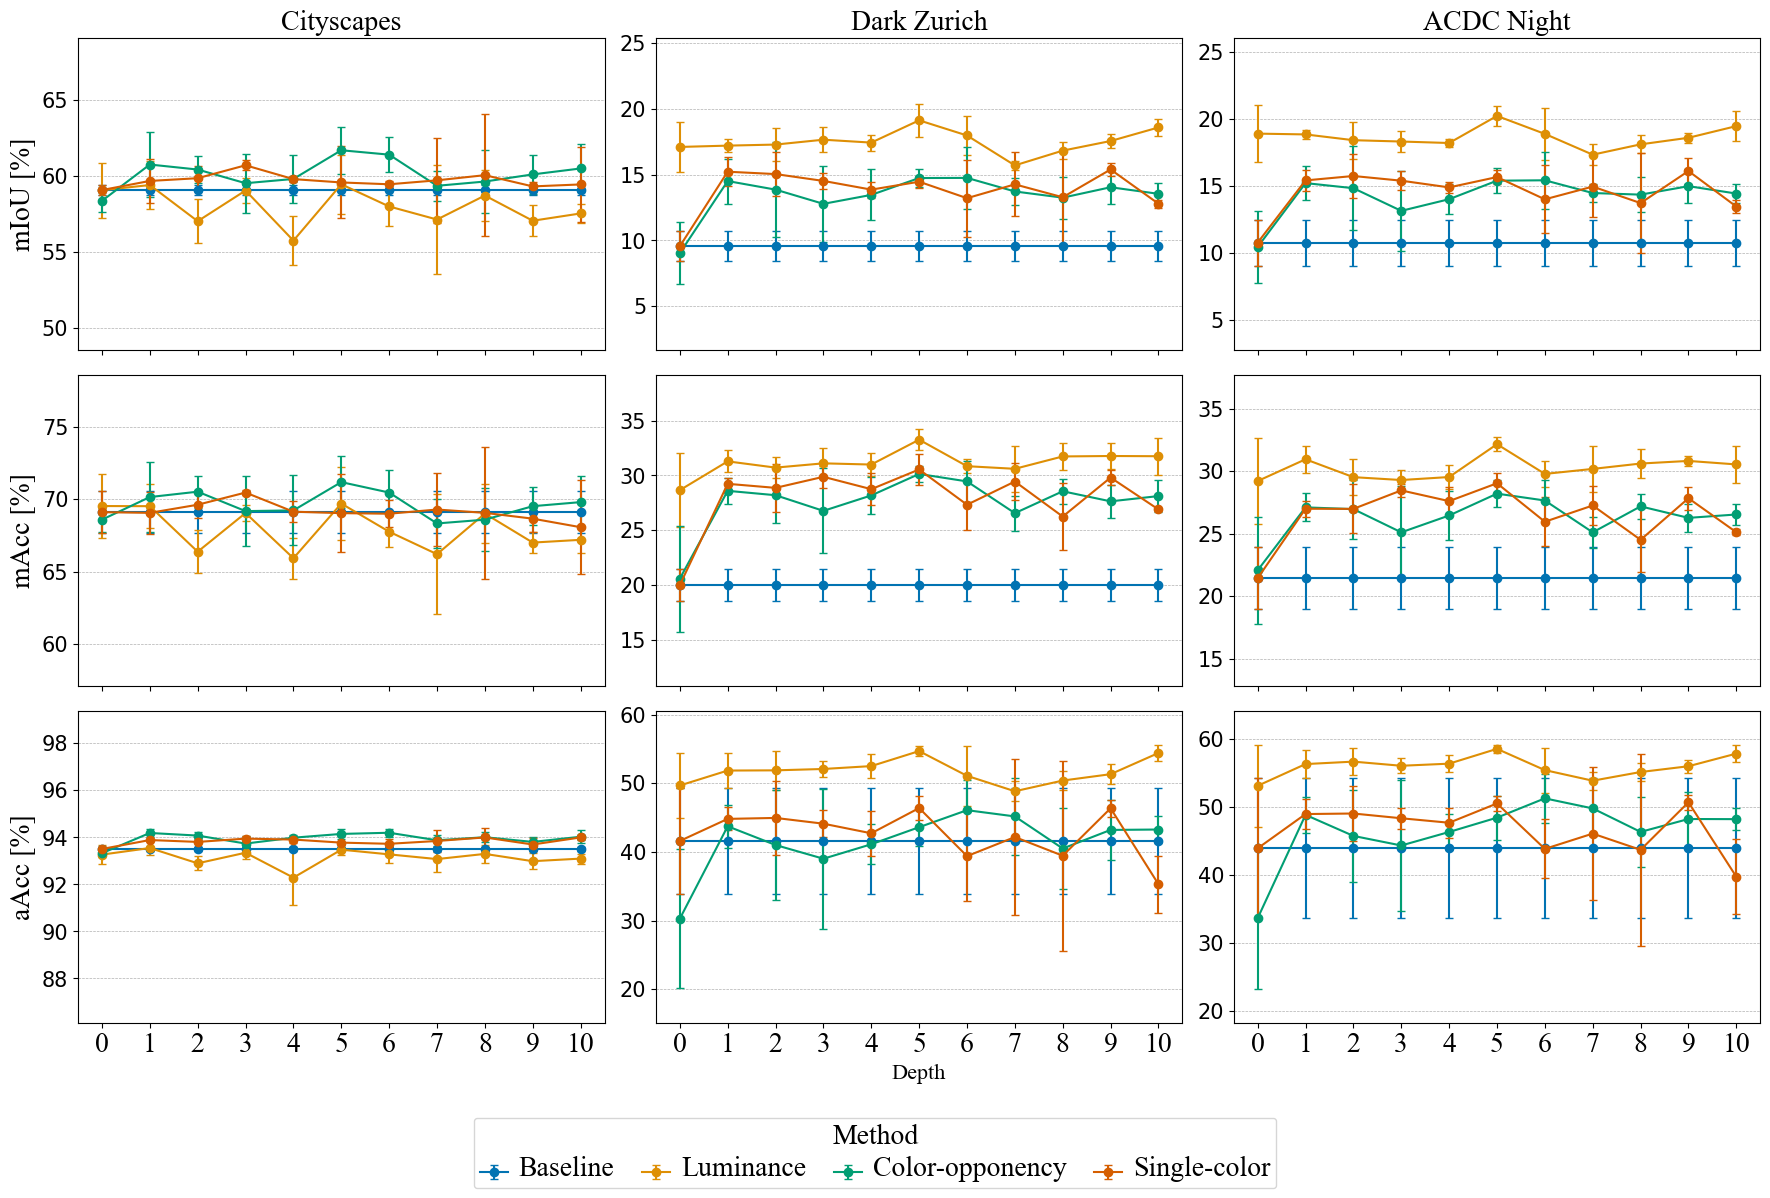

In [22]:
# Pfad zu Times New Roman (auf deinem System anpassen!)
font_path = "/home/lstracke/Data/times.ttf"  # Beispiel Linux-Pfad
times_new_roman = FontProperties(fname=font_path, size=16)
network_list = ["Deeplabv3+ (ResNet50)", "SegFormer", "UPerNet"]


latex_tables = {
    'cityscapes': r"""
    \begin{table*}[h]
    \begin{tabular}{@{}lcccccc@{}}
    Validation on cityscapes & preprocessing & dept  &  aAcc\_mean  & mIoU\_mean  & mAcc\_mean \\
    \midrule
    baseline & - & 0 & 93.51 ~$\pm$~ 0.08 & 59.09 ~$\pm$~ 0.30 & 69.10 ~$\pm$~ 1.45 \\
    bw\_d0 & bw\_average&0 & 93.27 ~$\pm$~ 0.39 & 59.08 ~$\pm$~ 1.82 & 69.52 ~$\pm$~ 2.22 \\
    bw\_d1 & bw\_average&1 & 93.55 ~$\pm$~ 0.30 & 59.42 ~$\pm$~ 1.56 & 69.51 ~$\pm$~ 1.52 \\
    bw\_d2 & bw\_average&2 & 92.90  ~$\pm$~ 0.29 & 57.04 ~$\pm$~ 1.43 & 66.37 ~$\pm$~ 1.48 \\
    bw\_d3 & bw\_average&3 & 93.35 ~$\pm$~ 0.25 & 59.06 ~$\pm$~ 0.81 & 69.04 ~$\pm$~ 0.54 \\
    bw\_d4 & bw\_average&4 & 92.29 ~$\pm$~ 1.17 & 55.76 ~$\pm$~ 1.61 & 65.92 ~$\pm$~ 1.41 \\
    bw\_d5 & bw\_average&5 & 93.48 ~$\pm$~ 0.22 & \textbf{59.47} ~$\pm$~ 1.96 & 69.69 ~$\pm$~ 2.49 \\
    bw\_d6 & bw\_average&6 & 93.28 ~$\pm$~ 0.37 & 58.01 ~$\pm$~ 1.30 & 67.75 ~$\pm$~ 1.08 \\
    bw\_d7 & bw\_average&7 & 93.08 ~$\pm$~ 0.53 & 57.15 ~$\pm$~ 3.60 & 66.20  ~$\pm$~ 4.12 \\
    bw\_d8 & bw\_average&8 & 93.30 ~$\pm$~ 0.39 & 58.73 ~$\pm$~ 1.67 & 69.00    ~$\pm$~ 2.04 \\
    bw\_d9 & bw\_average&9 & 92.99 ~$\pm$~ 0.34 & 57.07 ~$\pm$~ 1.01 & 67.00    ~$\pm$~ 0.71 \\
    bw\_d10 & bw\_average&10 & 93.10 ~$\pm$~ 0.21 & 57.55 ~$\pm$~ 0.61 & 67.19 ~$\pm$~ 0.94 \\
    \midrule
    co\_d0 & co &0 & 93.33 ~$\pm$~ 0.16 & 58.38 ~$\pm$~ 0.76 & 68.58 ~$\pm$~ 0.83 \\
    co\_d1 & co &1 & 94.19 ~$\pm$~ 0.16 & 60.77 ~$\pm$~ 2.16 & 70.14 ~$\pm$~ 2.39 \\
    co\_d2 & co &2 & 94.08 ~$\pm$~ 0.16 & 60.44 ~$\pm$~ 0.86 & 70.51 ~$\pm$~ 1.10 \\
    co\_d3 & co &3 & 93.74 ~$\pm$~ 0.32 & 59.54 ~$\pm$~ 1.95 & 69.17 ~$\pm$~ 2.40 \\
    co\_d4 & co &4 & 93.99 ~$\pm$~ 0.11 & 59.82 ~$\pm$~ 1.60 & 69.22 ~$\pm$~ 2.42 \\
    co\_d5 & co &5 & 94.15 ~$\pm$~ 0.20 & \textbf{61.71} ~$\pm$~ 1.55 & 71.17 ~$\pm$~ 1.79 \\
    co\_d6 & co &6 & 94.20 ~$\pm$~ 0.16 & 61.42 ~$\pm$~ 1.13 & 70.45 ~$\pm$~ 1.57 \\
    co\_d7 & co &7 & 93.88 ~$\pm$~ 0.23 & 59.37 ~$\pm$~ 0.99 & 68.32 ~$\pm$~ 1.71 \\
    co\_d8 & co &8 & 94.01 ~$\pm$~ 0.22 & 59.65 ~$\pm$~ 2.08 & 68.58 ~$\pm$~ 2.19 \\
    co\_d9 & co &9 & 93.81 ~$\pm$~ 0.23 & 60.12 ~$\pm$~ 1.30 & 69.51 ~$\pm$~ 1.33 \\
    co\_d10 & co &10 & 94.03 ~$\pm$~ 0.27 & 60.51 ~$\pm$~ 1.58 & 69.79 ~$\pm$~ 1.80 \\
    \midrule
    sc\_d0 & sc & 0 & 93.51 ~$\pm$~ 0.08 & 59.09 ~$\pm$~ 0.30 & 69.10 ~$\pm$~ 1.45 \\
    sc\_d1 & sc &1 & 93.89 ~$\pm$~ 0.28 & 59.69 ~$\pm$~ 1.46 & 69.05 ~$\pm$~ 1.47 \\
    sc\_d2 & sc &2 & 93.81 ~$\pm$~ 0.01 & 59.87 ~$\pm$~ 0.83 & 69.61 ~$\pm$~ 0.90 \\
    sc\_d3 & sc &3 & 93.95 ~$\pm$~ 0.11 & \textbf{60.72} ~$\pm$~ 0.32 & 70.45 ~$\pm$~ 0.18 \\
    sc\_d4 & sc &4 & 93.91 ~$\pm$~ 0.13 & 59.81 ~$\pm$~ 0.19 & 69.13 ~$\pm$~ 0.73 \\
    sc\_d5 & sc &5 & 93.78 ~$\pm$~ 0.32 & 59.59 ~$\pm$~ 2.37 & 69.03 ~$\pm$~ 2.71 \\
    sc\_d6 & sc &6 & 93.73 ~$\pm$~ 0.19 & 59.47 ~$\pm$~ 0.24 & 68.99 ~$\pm$~ 0.92 \\
    sc\_d7 & sc &7 & 93.85 ~$\pm$~ 0.48 & 59.73 ~$\pm$~ 2.78 & 69.28 ~$\pm$~ 2.53 \\
    sc\_d8 & sc &8 & 94.00 ~$\pm$~ 0.39 & 60.07 ~$\pm$~ 4.01 & 69.05 ~$\pm$~ 4.54 \\
    sc\_d9 & sc &9 & 93.70  ~$\pm$~ 0.27 & 59.33 ~$\pm$~ 0.26 & 68.65 ~$\pm$~ 0.91 \\
    sc\_d10 & sc &10 & 94.00 ~$\pm$~ 0.09 & 59.46 ~$\pm$~ 2.47 & 68.06 ~$\pm$~ 3.26 \\
    \end{tabular}
    """,

    'dark_zurich': r"""
    \begin{table*}[h]
    \begin{tabular}{@{}lcccccc@{}}
    \toprule
    Validation on dark\_zurich & preprocessing & dept    &  aAcc\_mean  & mIoU\_mean  & mAcc\_mean  \\
    \midrule
    baseline & - &0  & 41.60  ~$\pm$~ 7.74 & 9.56 ~$\pm$~ 1.13 & 20.00    ~$\pm$~ 1.43 \\
    \midrule
    bw\_d0 & bw\_average&0  & 49.69 ~$\pm$~ 4.81 & 17.10  ~$\pm$~ 1.87 & 28.66 ~$\pm$~ 3.39 \\
    bw\_d1 & bw\_average&1  & 51.87 ~$\pm$~ 2.61 & 17.20 ~$\pm$~ 0.49 & 31.29 ~$\pm$~ 1.00 \\
    bw\_d2 & bw\_average&2  & 51.90 ~$\pm$~ 2.88 & 17.28 ~$\pm$~ 1.26 & 30.72 ~$\pm$~ 0.95 \\
    bw\_d3 & bw\_average&3  & 52.10 ~$\pm$~ 1.20 & 17.65 ~$\pm$~ 0.96 & 31.11 ~$\pm$~ 1.38 \\
    bw\_d4 & bw\_average&4  & 52.52 ~$\pm$~ 1.72 & 17.43 ~$\pm$~ 0.60 & 31.00 ~$\pm$~ 1.06 \\
    bw\_d5 & bw\_average&5  & 54.71 ~$\pm$~ 0.79 & \textbf{19.12} ~$\pm$~ 1.23 & 33.27 ~$\pm$~ 0.95 \\
    bw\_d6 & bw\_average&6  & 51.10  ~$\pm$~ 4.42 & 17.97 ~$\pm$~ 1.50 & 30.85 ~$\pm$~ 0.65 \\
    bw\_d7 & bw\_average&7  & 48.85 ~$\pm$~ 1.45 & 15.70  ~$\pm$~ 0.33 & 30.61 ~$\pm$~ 2.10 \\
    bw\_d8 & bw\_average&8  & 50.41 ~$\pm$~ 1.43 & 16.82 ~$\pm$~ 0.65 & 31.74 ~$\pm$~ 1.21 \\
    bw\_d9 & bw\_average&9  & 51.34 ~$\pm$~ 1.47 & 17.55 ~$\pm$~ 0.53 & 31.78 ~$\pm$~ 1.19 \\
    bw\_d10 & bw\_average&10  & 54.43 ~$\pm$~ 1.16 & 18.58 ~$\pm$~ 0.67 & 31.76 ~$\pm$~ 1.69 \\
    \midrule
    co\_d0 & co &0  & 30.26 ~$\pm$~ 10.16 & 9.04 ~$\pm$~ 2.37 & 20.58 ~$\pm$~ 4.84 \\
    co\_d1 & co &1  & 43.74 ~$\pm$~ 3.12 & 14.51 ~$\pm$~ 1.71 & 28.60 ~$\pm$~ 1.21 \\
    co\_d2 & co &2  & 41.01 ~$\pm$~ 8.00 & 13.86 ~$\pm$~ 3.62 & 28.20 ~$\pm$~ 2.55 \\
    co\_d3 & co &3  & 39.01 ~$\pm$~ 10.23 & 12.78 ~$\pm$~ 2.87 & 26.77 ~$\pm$~ 3.87 \\
    co\_d4 & co &4  & 41.12 ~$\pm$~ 2.91 & 13.46 ~$\pm$~ 1.93 & 28.18 ~$\pm$~ 1.70 \\
    co\_d5 & co &5  & 43.61 ~$\pm$~ 2.77 & 14.74 ~$\pm$~ 0.67 & 30.14 ~$\pm$~ 0.69 \\
    co\_d6 & co &6  & 46.09 ~$\pm$~ 4.39 & \textbf{14.75} ~$\pm$~ 2.33 & 29.46 ~$\pm$~ 1.85 \\
    co\_d7 & co &7  & 45.18 ~$\pm$~ 5.57 & 13.72 ~$\pm$~ 1.04 & 26.56 ~$\pm$~ 1.60 \\
    co\_d8 & co &8  & 40.50 ~$\pm$~ 5.87 & 13.25 ~$\pm$~ 1.59 & 28.56 ~$\pm$~ 1.16 \\
    co\_d9 & co &9  & 43.21 ~$\pm$~ 4.35 & 14.04 ~$\pm$~ 1.28 & 27.64 ~$\pm$~ 1.49 \\
    co\_d10 & co &10  & 43.27 ~$\pm$~ 1.95 & 13.54 ~$\pm$~ 0.84 & 28.12 ~$\pm$~ 1.48 \\
    \midrule
    sc\_d0 & sc &0  & 41.60  ~$\pm$~ 7.74 & 9.56 ~$\pm$~ 1.13 & 20.00    ~$\pm$~ 1.43 \\
    sc\_d1 & sc &1  & 44.82 ~$\pm$~ 1.69 & 15.22 ~$\pm$~ 1.10 & 29.24 ~$\pm$~ 0.53 \\
    sc\_d2 & sc &2  & 44.96 ~$\pm$~ 5.36 & 15.04 ~$\pm$~ 1.65 & 28.87 ~$\pm$~ 2.18 \\
    sc\_d3 & sc &3  & 44.12 ~$\pm$~ 1.95 & 14.52 ~$\pm$~ 0.62 & 29.88 ~$\pm$~ 1.00 \\
    sc\_d4 & sc &4  & 42.72 ~$\pm$~ 3.25 & 13.86 ~$\pm$~ 0.61 & 28.75 ~$\pm$~ 1.45 \\
    sc\_d5 & sc &5  & 46.40  ~$\pm$~ 1.72 & 14.46 ~$\pm$~ 0.46 & 30.55 ~$\pm$~ 1.40 \\
    sc\_d6 & sc &6  & 39.39 ~$\pm$~ 6.55 & 13.21 ~$\pm$~ 2.91 & 27.33 ~$\pm$~ 2.33 \\
    sc\_d7 & sc &7  & 42.17 ~$\pm$~ 11.35 & 14.26 ~$\pm$~ 2.43 & 29.45 ~$\pm$~ 1.66 \\
    sc\_d8 & sc &8  & 39.45 ~$\pm$~ 13.88 & 13.28 ~$\pm$~ 3.56 & 26.25 ~$\pm$~ 3.08 \\
    sc\_d9 & sc &9  & 46.37 ~$\pm$~ 1.24 & \textbf{15.39} ~$\pm$~ 0.48 & 29.81 ~$\pm$~ 0.69 \\
    sc\_d10 & sc &10  & 35.29 ~$\pm$~ 4.19 & 12.79 ~$\pm$~ 0.31 & 26.90 ~$\pm$~ 0.17 \\
    \end{tabular}
    """,

    'acdc_night': r"""
    \begin{table*}[h]
    \centering
    \begin{tabular}{@{}lcccccc@{}}
    \toprule
    Validation on acdc\_night & preprocessing & dept   &  aAcc\_mean  & mIoU\_mean  & mAcc\_mean \\
    \midrule
    baseline & - &0 & 43.89 ~$\pm$~ 10.31 & 10.77 ~$\pm$~ 1.72 & 21.44 ~$\pm$~ 2.50 \\
    \midrule
    bw\_d0 & bw\_average&0 & 53.10 ~$\pm$~ 6.04 & 18.90  ~$\pm$~ 2.11 & 29.22 ~$\pm$~ 3.41 \\
    bw\_d1 & bw\_average&1 & 56.30  ~$\pm$~ 2.12 & 18.84 ~$\pm$~ 0.36 & 30.96 ~$\pm$~ 1.06 \\
    bw\_d2 & bw\_average&2 & 56.66 ~$\pm$~ 1.98 & 18.41 ~$\pm$~ 1.39 & 29.53 ~$\pm$~ 1.43 \\
    bw\_d3 & bw\_average&3 & 56.05 ~$\pm$~ 1.12 & 18.31 ~$\pm$~ 0.78 & 29.30 ~$\pm$~ 0.83 \\
    bw\_d4 & bw\_average&4& 56.36 ~$\pm$~ 1.25 & 18.20  ~$\pm$~ 0.31 & 29.54 ~$\pm$~ 0.94 \\
    bw\_d5 & bw\_average&5 & 58.54 ~$\pm$~ 0.61 & \textbf{20.22} ~$\pm$~ 0.74 & 32.17 ~$\pm$~ 0.58 \\
    bw\_d6 & bw\_average&6 & 55.41 ~$\pm$~ 3.31 & 18.88 ~$\pm$~ 1.95 & 29.79 ~$\pm$~ 1.04 \\
    bw\_d7 & bw\_average&7 & 53.85 ~$\pm$~ 1.32 & 17.33 ~$\pm$~ 0.80 & 30.19 ~$\pm$~ 1.81 \\
    bw\_d8 & bw\_average&8 & 55.13 ~$\pm$~ 1.29 & 18.10 ~$\pm$~ 0.67 & 30.62 ~$\pm$~ 1.17 \\
    bw\_d9 & bw\_average&9 & 55.98 ~$\pm$~ 0.97 & 18.59 ~$\pm$~ 0.38 & 30.83 ~$\pm$~ 0.38 \\
    bw\_d10 & bw\_average&10 & 57.84 ~$\pm$~ 1.21 & 19.46 ~$\pm$~ 1.10 & 30.55 ~$\pm$~ 1.49 \\
    \midrule
    co\_d0 & co &0 & 33.60 ~$\pm$~ 10.38 & 10.45 ~$\pm$~ 2.70 & 22.07 ~$\pm$~ 4.30 \\
    co\_d1 & co &1 & 48.82 ~$\pm$~ 2.67 & 15.21 ~$\pm$~ 1.28 & 27.11 ~$\pm$~ 1.12 \\
    co\_d2 & co &2 & 45.72 ~$\pm$~ 6.83 & 14.83 ~$\pm$~ 3.13 & 26.97 ~$\pm$~ 2.36 \\
    co\_d3 & co &3 & 44.31 ~$\pm$~ 9.65 & 13.14 ~$\pm$~ 3.00 & 25.11 ~$\pm$~ 3.70 \\
    co\_d4 & co &4 & 46.30  ~$\pm$~ 2.72 & 14.01 ~$\pm$~ 1.13 & 26.46 ~$\pm$~ 2.00 \\
    co\_d5 & co &5 & 48.41 ~$\pm$~ 3.25 & 15.39 ~$\pm$~ 0.92 & 28.21 ~$\pm$~ 1.08 \\
    co\_d6 & co &6 & 51.25 ~$\pm$~ 3.56 & \textbf{15.42} ~$\pm$~ 2.11 & 27.66 ~$\pm$~ 1.64 \\
    co\_d7 & co &7 & 49.77 ~$\pm$~ 4.07 & 14.47 ~$\pm$~ 0.70 & 25.11 ~$\pm$~ 1.22 \\
    co\_d8 & co &8 & 46.31 ~$\pm$~ 5.14 & 14.35 ~$\pm$~ 1.29 & 27.19 ~$\pm$~ 0.99 \\
    co\_d9 & co &9 & 48.21 ~$\pm$~ 3.93 & 14.98 ~$\pm$~ 1.26 & 26.27 ~$\pm$~ 1.13 \\
    co\_d10 & co &10 & 48.19 ~$\pm$~ 1.63 & 14.43 ~$\pm$~ 0.71 & 26.54 ~$\pm$~ 0.88 \\
    \midrule
    sc\_d0 & sc &0 & 43.89 ~$\pm$~ 10.31 & 10.77 ~$\pm$~ 1.72 & 21.44 ~$\pm$~ 2.50 \\
    sc\_d1 & sc &1 & 48.94 ~$\pm$~ 2.23 & 15.41 ~$\pm$~ 0.76 & 27.00 ~$\pm$~ 0.65 \\
    sc\_d2 & sc &2 & 49.02 ~$\pm$~ 4.01 & 15.74 ~$\pm$~ 1.62 & 26.99 ~$\pm$~ 1.96 \\
    sc\_d3 & sc &3 & 48.32 ~$\pm$~ 1.51 & 15.39 ~$\pm$~ 0.69 & 28.47 ~$\pm$~ 0.52 \\
    sc\_d4 & sc &4 & 47.66 ~$\pm$~ 2.24 & 14.89 ~$\pm$~ 0.42 & 27.61 ~$\pm$~ 1.15 \\
    sc\_d5 & sc &5 & 50.50  ~$\pm$~ 1.05& \textbf{15.66} ~$\pm$~ 0.52 & 29.04~$\pm$~ 0.85 \\
    sc\_d6 & sc &6 & 43.81 ~$\pm$~ 4.35 & 14.00~$\pm$~ 2.53 & 25.96 ~$\pm$~ 1.95 \\
    sc\_d7 & sc &7 & 46.06 ~$\pm$~ 9.81 & 14.95 ~$\pm$~ 2.25 & 27.26~$\pm$~ 1.59 \\
    sc\_d8 & sc &8 & 43.67 ~$\pm$~ 14.13& 13.72 ~$\pm$~ 3.72 & 24.51~$\pm$~ 2.59 \\
    sc\_d9 & sc &9 & 50.67 ~$\pm$~ 1.09 & 16.11 ~$\pm$~ 0.99 & 27.84~$\pm$~ 0.94 \\
    sc\_d10 & sc &10 & 39.71 ~$\pm$~ 5.56 & 13.46 ~$\pm$~ 0.50 & 25.12 ~$\pm$~ 0.25 \\
    \end{tabular}
    """
}


def extract_val_std(s):
    s_orig = s
    s = s.replace('$', '').replace('~', '').strip()
    # \pm oder pm -> ersetze durch Trennzeichen
    s = re.sub(r'\\?pm', '|', s)
    # entferne übrige LaTeX-Kommandos
    s = re.sub(r'\\[a-zA-Z]+\{?', '', s)
    # nur erlaubte Zeichen (Ziffern, Punkt, Minus, Pipe, Leer)
    s = re.sub(r'[^0-9.\-|\s]', '', s)
    if '|' in s:
        parts = [p.strip() for p in s.split('|') if p.strip()]
    else:
        parts = [p.strip() for p in s.split() if p.strip()]
    if len(parts) == 2:
        return float(parts[0]), float(parts[1])
    elif len(parts) == 1:
        return float(parts[0]), 0.0
    else:
        # Fallback: suche Zahlen per regex
        nums = re.findall(r'[\d.]+', s)
        if len(nums) >= 2:
            return float(nums[0]), float(nums[1])
        elif len(nums) == 1:
            return float(nums[0]), 0.0
        raise ValueError(f"Unrecognized format: '{s_orig}' -> cleaned '{s}', parts: {parts}, nums:{nums}")

# -------------------------
# Parse alle latex_tables in DataFrame (6- oder 7-spaltig)
# -------------------------
all_rows = []
for dataset, latex in latex_tables.items():
    for line in latex.splitlines():
        line = line.strip()
        if not line or line.startswith('%'):
            continue
        if '&' not in line or '~' not in line:
            continue
        # trailing \\ entfernen
        line = re.sub(r'\\\\\s*$', '', line)
        parts = [p.strip() for p in line.split('&') if p.strip()]
        if len(parts) == 6:
            run, prep, depth_str, aAcc_str, mIoU_str, mAcc_str = parts
        elif len(parts) == 7:
            run, prep, depth_str, channel, aAcc_str, mIoU_str, mAcc_str = parts
        else:
            continue
        # depth parsen
        try:
            depth = int(re.sub(r'[^0-9\-]', '', depth_str))
        except:
            continue
        try:
            aAcc_mean, aAcc_std = extract_val_std(aAcc_str)
            mIoU_mean, mIoU_std = extract_val_std(mIoU_str)
            mAcc_mean, mAcc_std = extract_val_std(mAcc_str)
        except Exception as e:
            print("Skipping row (parse error):", parts, e)
            continue
        run_clean = run.replace('\\', '').strip()
        # Methode extrahieren (wie in deinem Beispiel)
        def extract_method_single(r):
            r_low = r.lower()
            if 'baseline' in r_low:
                return 'baseline'
            if 'bw' in r_low:
                return 'bw_average'
            if 'co' in r_low:
                return 'co'
            if 'sc' in r_low:
                return 'sc'
            return 'other'
        method = extract_method_single(run_clean)
        all_rows.append({
            'dataset': dataset,
            'run': run_clean,
            'method': method,
            'preprocessing': prep,
            'depth': depth,
            'aAcc_mean': aAcc_mean,
            'aAcc_std': aAcc_std,
            'mIoU_mean': mIoU_mean,
            'mIoU_std': mIoU_std,
            'mAcc_mean': mAcc_mean,
            'mAcc_std': mAcc_std,
        })

df = pd.DataFrame(all_rows)
if df.empty:
    raise RuntimeError("Kein Datensatz gefunden — prüfe 'latex_tables' Inhalt/Format.")


# -------------------------
# Datasets / Metrics / Depths
# -------------------------
datasets_order = ["cityscapes", "dark_zurich", "acdc_night"]  # Spaltenreihenfolge wie gewünscht
metrics = [
    ('mIoU_mean', 'mIoU_std', 'mIoU [%]'),
    ('mAcc_mean', 'mAcc_std', 'mAcc [%]'),
    ('aAcc_mean', 'aAcc_std', 'aAcc [%]')
]
depths_all = np.arange(0, 11)  # 0..10 als x-axis

# -------------------------
# fixed ordering / labels / colors (näher am Original)
# -------------------------
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# fixed ordering / labels / colors (näher am Original)
# -------------------------
method_order = ['baseline', 'bw_average', 'co', 'sc']
display_names = {
    'baseline': 'Baseline',
    'bw_average': 'Luminance',
    'co': 'Color-opponency',
    'sc': 'Single-color',
    'other': 'Other'
}

# benutze seaborn colorblind palette; baseline ist jetzt die erste Farbe daraus
palette_list = sns.color_palette("colorblind", n_colors=len(method_order))
color_map = {method_order[i]: palette_list[i] for i in range(len(method_order))}

def get_color(m):
    return color_map.get(m, 'gray')
def get_label(m):
    return display_names.get(m, m)

# -------------------------
# Datasets / Metrics / Depths (wie vorher)
# -------------------------
datasets_order = ["cityscapes", "dark_zurich", "acdc_night"]  # Spaltenreihenfolge wie gewünscht
metrics = [
    ('mIoU_mean', 'mIoU_std', 'mIoU [%]'),
    ('mAcc_mean', 'mAcc_std', 'mAcc [%]'),
    ('aAcc_mean', 'aAcc_std', 'aAcc [%]')
]
depths_all = np.arange(0, 11)  # 0..10 als x-axis

# -------------------------
# FIGURE A (abstract): 3 rows (metrics) x 3 cols (datasets)
# -------------------------
nrows = len(metrics)
ncols = len(datasets_order)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6*ncols, 4*nrows), sharex='col')
if ncols == 1:
    axes = axes[:, np.newaxis]

for row_idx, (mean_col, std_col, ylabel) in enumerate(metrics):
    for col_idx, ds in enumerate(datasets_order):
        ax = axes[row_idx, col_idx]

        # --- Baseline: konstante Mean über alle Depths, mit Fehlerbalken; Farbe aus palette ---
        baseline_df = df[(df['dataset'] == ds) & (df['method'] == 'baseline')]
        if not baseline_df.empty:
            if (baseline_df['depth'] == 0).any():
                b0 = baseline_df[baseline_df['depth'] == 0].iloc[0]
            else:
                b0 = baseline_df.iloc[0]
            base_mean = b0[mean_col]
            base_std  = b0[std_col]
            ax.errorbar(depths_all,
                        [base_mean]*len(depths_all),
                        yerr=[base_std]*len(depths_all),
                        marker='o', linestyle='-', capsize=3,
                        label=get_label('baseline'),
                        color=get_color('baseline'))

        # --- Andere Methoden: nur Errorbars pro Punkt (keine fill_between) ---
        for method in method_order:
            if method == 'baseline':
                continue
            subset = df[(df['dataset'] == ds) & (df['method'] == method)]
            ys = np.array([np.nan]*len(depths_all))
            yerr = np.array([np.nan]*len(depths_all))
            for i, d in enumerate(depths_all):
                row = subset[subset['depth'] == d]
                if not row.empty:
                    ys[i] = row[mean_col].values[0]
                    yerr[i] = row[std_col].values[0]
            if np.all(np.isnan(ys)):
                continue
            ax.errorbar(depths_all, ys, yerr=yerr, marker='o', linestyle='-', capsize=3,
                        label=get_label(method), color=get_color(method))

        # --- Achsenbeschriftungen ---
        if col_idx == 0:
            ax.set_ylabel(ylabel, fontproperties=times_new_roman, fontsize=20)
        ax.set_xticks(depths_all)
        if row_idx == nrows - 1:
            if col_idx == 1:
                ax.set_xlabel("Depth", fontproperties=times_new_roman)
            ax.set_xticklabels([str(d) for d in depths_all], fontproperties=times_new_roman, fontsize=20)
        else:
            ax.set_xticklabels([])

        # --- Dataset-Titel nur in oberster Zeile ---
        if row_idx == 0:
            pretty_names = {'cityscapes': 'Cityscapes', 'dark_zurich': 'Dark Zurich', 'acdc_night': 'ACDC Night'}
            ax.set_title(pretty_names.get(ds, ds), fontproperties=times_new_roman,fontsize=20)
        else:
            ax.set_title("")

        ax.grid(True, axis='y', linestyle='--', linewidth=0.5)
        all_y_values = []

        # Baseline-Werte
        baseline_df = df[(df['dataset'] == ds) & (df['method'] == 'baseline')]
        if not baseline_df.empty:
            if (baseline_df['depth'] == 0).any():
                b0 = baseline_df[baseline_df['depth'] == 0].iloc[0]
            else:
                b0 = baseline_df.iloc[0]
            base_mean = b0[mean_col]
            base_std = b0[std_col]
            all_y_values.extend([base_mean - base_std, base_mean + base_std])

        # Andere Methoden-Werte
        for method in method_order:
            if method == 'baseline':
                continue
            subset = df[(df['dataset'] == ds) & (df['method'] == method)]
            for d in depths_all:
                row = subset[subset['depth'] == d]
                if not row.empty:
                    mean_val = row[mean_col].values[0]
                    std_val = row[std_col].values[0]
                    all_y_values.extend([mean_val - std_val, mean_val + std_val])

        if len(all_y_values) > 0:
            ymin = max(0, min(all_y_values) - 5)  # etwas Puffer nach unten, nicht < 0
            ymax = min(100, max(all_y_values) + 5)  # Puffer nach oben, max 100
            ax.set_ylim(ymin, ymax)
            ax.tick_params(axis='y', labelsize=15)
        else:
            ax.set_ylim(0, 100)  # Fallback
            ax.tick_params(axis='y', labelsize=15)

# Legend (einmalig, dedupliziert)
legend_ax = axes[0, -1]
handles, labels = legend_ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
legend = fig.legend(
    by_label.values(),
    by_label.keys(),
    title="Method",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.00),
    ncol=4
)
for text in legend.get_texts():
    text.set_fontproperties(times_new_roman)
    text.set_fontsize(20)

legend.get_title().set_fontproperties(times_new_roman)
legend.get_title().set_fontsize(20)

fig.tight_layout(rect=[0,0.08,1,1])
out1 = "/home/lstracke/blur_preprocessing/blur_preprocessing_git/visualization/ablation_depth_appendix.pdf"
plt.savefig(out1, dpi=800, bbox_inches='tight')
#df.to_csv("visualization/ablation_depth_appendix.csv", index=False)

plt.show()